# 4. Map predictions back onto the fine-resolution depth grid

`02_inference.ipynb` predicts one grain type per 1 mm depth bin. This combines
those predictions with the fine-resolution campaign file from
`00_preprocessing.ipynb` and assigns every raw depth sample the label of the
bin it falls into, via `remapping.remap_predictions_to_fine_resolution`.

In [1]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import xarray as xr

import config
import remapping

## Load the fine-resolution profiles and the predictions

`coarse` is whatever `02_inference.ipynb` wrote to `outputs/` — running it
unchanged against the shipped `data/unlabelled/PS111_profiles.nc` writes
`outputs/PS111_profiles_with_predictions.nc`, which is what's loaded here.

In [2]:
fine = xr.open_dataset(config.REPO_ROOT / "data" / "raw" / "PS111_profiles.nc")
coarse = xr.open_dataset(config.REPO_ROOT / "outputs" / "PS111_profiles_with_predictions.nc")

print(f"fine: {fine.sizes['profile']} profiles, {fine.sizes['sample']} samples")
print(f"coarse: {coarse.sizes['profile']} profiles, {coarse.sizes['depth_bins']} depth bins")

fine: 144 profiles, 118819 samples
coarse: 168 profiles, 491 depth bins


## Remap

In [3]:
remapped = remapping.remap_predictions_to_fine_resolution(fine, coarse)

matched = int(remapped.predicted_labels.notnull().any(dim="sample").sum())
print(f"{matched} of {remapped.sizes['profile']} profiles matched a prediction")

116 of 144 profiles matched a prediction


## Sanity check

Force trace and predicted grain type against the original, fine-resolution
depth for one profile.

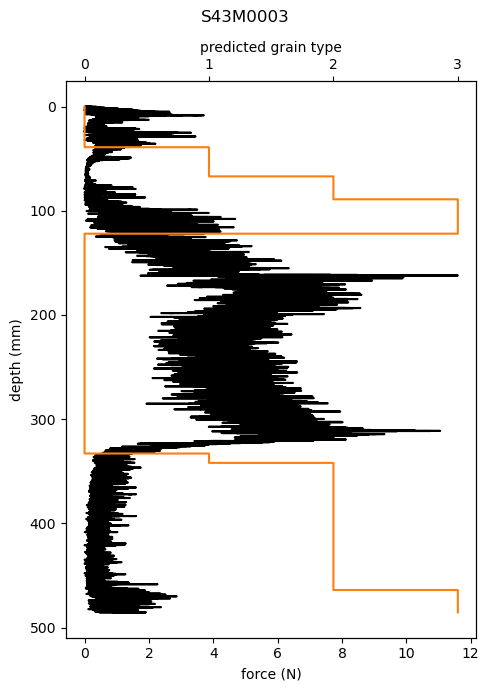

In [4]:
profile_index = 0
profile = remapped.isel(profile=profile_index)

figure, ax_force = plt.subplots(figsize=(5, 7))
ax_force.plot(profile.force, profile.depth, color="black")
ax_force.set_xlabel("force (N)")
ax_force.set_ylabel("depth (mm)")
ax_force.invert_yaxis()

ax_labels = ax_force.twiny()
ax_labels.plot(profile.predicted_labels, profile.depth, color="C1", drawstyle="steps-mid")
ax_labels.set_xlabel("predicted grain type")
ax_labels.set_xticks(range(config.NUM_CLASSES))

figure.suptitle(str(profile.name.item()))
figure.tight_layout()
plt.show()

## Write the result

In [5]:
output_path = config.REPO_ROOT / "outputs" / "PS111_profiles_fine_with_predictions.nc"
remapped.to_netcdf(output_path, mode="w", format="NETCDF4", engine="netcdf4")
print(f"wrote {output_path}")

wrote /home/dariapaul/work/01_proj_smp/code_publication/smp-cnn/outputs/PS111_profiles_fine_with_predictions.nc
